In [1]:
import torch
from matplotlib import pyplot as plt
import bound_propagation as bp
from linear_bound_propagation import Linear, factory as linear_factory

factory = bp.BoundModelFactory()

In [2]:
def mat_norm(mat, rho_):
    return torch.linalg.matrix_norm(mat, ord=rho_, dim=(-2, -1))

def vec_norm(vec, rho_):
    return torch.linalg.vector_norm(vec, ord=rho_, dim=-1)

def get_vertices(hyper_rectangle):
    l, u = hyper_rectangle.lower, hyper_rectangle.upper
    return torch.stack([l, torch.tensor([u[0], l[1]]), u, torch.tensor([l[0], u[1]]), l])

def inf_to_large(tensor):
    return tensor.clip(-1e7, 1e7)

# Problem
Given a function $f$, input region $X$ and an input point $c$, find scalars $\alpha$ and $\beta$ such that for all $x\in X$:

$$
\|f(x) - f(c)\|^\rho \leq \alpha \|x-c\|^\rho + \beta
$$

## Current Approach: Linear Bound Propagation
Our current approach assumes that there exists a $X$-partition $S$ such that for each region $S_i$ there exists linear maps $\check{A}_i(x-c)$ and $\hat{A}_i(x-c)$ satisfying
$$
\check{A}_i(x-c) \preceq f(x) - f(c) \preceq \hat{A}_i(x-c).
$$
for all $x\in X_i$. If such partition and mappings exist, then
$$
\|f(x) - f(c)\|^\rho \leq \alpha \|x-c\|^\rho
$$ 
where $\alpha = \max_{k\in \{1,...,|S|\}} \max(\|\check{A}_k\|^\rho, \|\hat{A}_k\|^\rho)$.

Finding the linear mappings for any $f$ is non-trivial. First of all, note that for the linear mapping to exists for any non-linear dynamics $f$, the partition $S$ should be such that the point $c$ is on the boundary of each region $S_i$, i.e., the partition $S$ resemble a star-like decomposition, where each region “radiates” outward from point $c$. 

Given an $S_i$ with $c$ on its boundaries, we rely on bound propagation (BP) to find the linear mapping for $S_i$. The BP algorithm can be summarized as follows:
1. We first decompose $f$ into operations for which we can efficiently compute linear/affine/interval maps. 
2. We then determine the input region for each operation by propagating $S_i$ through $f$.
3. Next, we compute the bounding maps for each operation w.r.t. the respective input region as constructed in step 2. 
4. Finally, we iteratively combine these bounds (in a backward manner) to obtain bounds on $f$.

Note that step 2 might require relaxing the input regions. To see this, consider $f(x) = \bar{\sigma}(x)$ with $\bar{\sigma}$ denoting the element-wise application of non-linear scalar operation $\sigma$, i.e., $f(x) = (\sigma(x_1), ..., \sigma(x_n))^T$ (e.g. $\sigma$ is the ReLU activation). Assume that the BP algorithm includes an efficient procedures to compute bounds on $\zeta\rightarrow \sigma(\zeta)$, for $\zeta\in [\check{\zeta}, \hat{\zeta}]$. In this event, we decompose $f$ over each input dimension $i$, and set the input region for the $i$ dimension to $[\inf_{x\in S}x_i, \sup_{x\in S}x_i]$, i.e., we relax $S$ by an hyper-rectangle. 

### Limitation: Restricted to Seperable dynamics
Compared to standard BP, we have the additional constraint that the linear relaxation of function $f$ over imput region $S_i$ should intersect $c$. To achieve this using the standard BP procedure, all the relaxations derived in step 3 should intersect with the mapped $c$. Recall that, for any non-linear operation, such linear mappings only exist if for each primitive operations $\tilde{c}$ is on the boundary of the respective input region. In case that the relaxation in step 2, causes $c$ to be located in the interior or the input region, the BP algorithm will fail to find a linear map in step 3. 

To illustrate this, consider $f(x)=sigmoid(Ax)$ with $A=\begin{bmatrix}0.2 & 0.7 \\ 0.7 & 0.2 \end{bmatrix}$, $S_i = [-1,1]\times [-1,1]$ and $c=(1,-1)^T$. 

In [3]:
A = torch.tensor([[0.2, 0.7], [0.7, 0.2]])
act = torch.nn.Sigmoid()
S = bp.HyperRectangle(-torch.ones(2), torch.ones(2))
c = torch.tensor([1.,-1.])

We decompese $f$ in the linear operation $z=Ax$ and the activation operation $y=tanh(z)$. In order to compute linear bounds for the activation operation, we relax $Image(A,S)$ by an hyper-rectangle denoted as $H$. Since $Ac$ falls in the interior of the hyper-rectangle $H$, no linear relaxtion of $z_i \rightarrow tanh(z_i)$ for $z_i\in Image(e_i, H)$ that interesects with $A_{i:}c$ can be found, for $i\in\{1,2\}$. 

In [4]:
S_vert = get_vertices(S) 

S_act_vert = torch.einsum('ij,...j->...i', A, S_vert)
S_act_hyper = bp.HyperRectangle(A @ S.lower, A @ S.upper)
c_act = A @ c

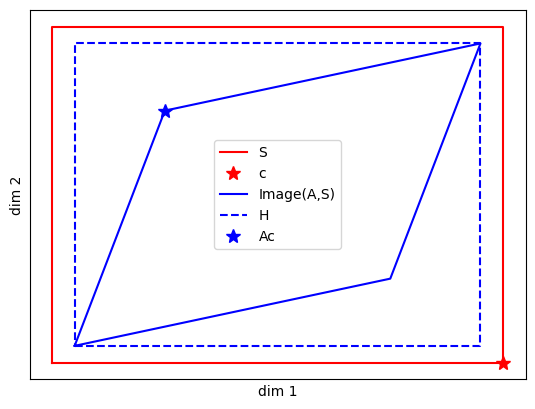

In [5]:
fig, ax = plt.subplots()

_ = ax.plot(*S_vert.t(), 'r-', label='S')
_ = ax.plot(*c, '*r', label='c', markersize=10)
_ = ax.plot(*S_act_vert.t(), 'b-', label='Image(A,S)')
_ = ax.plot(*get_vertices(S_act_hyper).t(), 'b--', label='H')
_ = ax.plot(*c_act, '*b', label='Ac', markersize=10)
_ = ax.legend()
_ = ax.set_xticks([])
_ = ax.set_xticklabels([])
_ = ax.set_yticks([])
_ = ax.set_yticklabels([])
_ = ax.set_xlabel('dim 1')
_ = ax.set_ylabel('dim 2')

In the special case of $f$ being an seperable function and $S$ being an hyper-rectangle, the input region of any operation in $f$ is an hyper-rectangle, and hence no relaxations will be required in step 2. Hence, if $c$ is on the boundary of $S$, the transformed $c$ is on the boundardy of any input region. 

## Alternative Approach 1: Affine Bound Propagation

Assumes that there exists a $X$-partition $S$ such that for each region $S_i$ there exists affine maps $\check{A}_i(x-c) + \check{b}_i$ and $\hat{A}_i(x-c) + \hat{b}_i$ satisfying
$$
\check{A}_i(x-c) + \check{b}_i \preceq f(x) - f(c) \preceq \hat{A}_i(x-c) + \hat{b}_i,
$$
for all $x\in S_i$. If such partition and mappings exist, then for $\rho=1$ or any **even** $\rho$, and $x\in S_i$ we have
\begin{align*}
    \|f(x) - f(c)\|^\rho &\leq \max(\|\check{A}_i(x-c) + \check{b}_i)\|^\rho, \|\hat{A}_i(x-c) + \hat{b}_i\|^\rho)\\
     &\leq 2^{\rho-1}\max(\|\check{A}_i(x-c)\|^\rho + \|\check{b}_i\|^\rho, \|\hat{A}_i(x-c)\|^\rho + \|\hat{b}_i\|^\rho)\\
     &\leq 2^{\rho-1}\max(\|\check{A}_1\|^\rho\|x-c\|^\rho + \|\check{b}_i\|^\rho, \|\hat{A}_i\|^\rho\|x-c\|^\rho + \|\hat{b}_i\|^\rho)\\ 
     &\leq 2^{\rho-1}\left[\max(\|\check{A}_i\|^\rho, \|\hat{A}_i\|^\rho\|)\|x-c\|^\rho + \max(\|\check{b}_i\|^\rho,\|\hat{b}_i\|^\rho)\right],
    \end{align*}
where in step 2 we use that for any even integer $\rho$, the function $z\mapsto z^\rho$ is convex, and hence $((x+y)/ 2)^\rho \leq (x^\rho+y^\rho)/2$.

## Alternative Approach 2: Local Taylor Expansion

Consider the Local Taylor expansion of $f$ around $c$,
$$
f(x) = f(c) + \nabla f(c)[x-c]_a^b\cdot\mathbb{1}_Q(x) + R(x)
$$
where $R(x)$ is the remainder term, and $[x-c]_a^b = \max(a,\min(b, x-c))$. For any **even** $\rho$ this gives
\begin{align*}
    \|f(x) - f(c)\|^\rho &\leq \|\nabla f(c)[x-c]_a^b + R(x)\|^\rho \\ 
    &\leq 2^{\rho-1}(\|\nabla f(c)[x-c]_a^b\| + \|R(x)\|^\rho) \\
    &\leq 2^{\rho-1}\left[\|\nabla f(c)\|^\rho \|[x-c]_a^b\|^\rho + \max(\|\sup_{x\in X} R(x)\|^\rho, \|\inf_{x\in X} R(x)\|^\rho) \right] \\
    &\leq 2^{\rho-1}\left[\|\nabla f(c)\|^\rho \|x-c\|^\rho + \max(\|\sup_{x\in X} R(x)\|^\rho, \|\inf_{x\in X} R(x)\|^\rho) \right]
\end{align*}
Note that the sup and inf of the remainder term over $X$ can be computed using standard bound propagation.

### Alternative Approach 1 vs Alternative Approach 2 
In contrast to the LBP-approach, this alternative approach is able to handle the non-seperable dynamics defined in the former section, as illustrated below for $\rho=1$.

In [6]:
rho = 1
f = torch.nn.Sequential(Linear(A), act)

# Approach 1
ab = factory.build(f).crown(bp.HyperRectangle(S.lower.unsqueeze(0), S.upper.unsqueeze(0)))

alpha_1 = 2 ** (rho - 1) * max(mat_norm(ab.lower[0], rho), mat_norm(ab.upper[0], rho)).pow(rho)
beta_1 = 2 ** (rho - 1) * max(mat_norm(ab.lower[1] - ab.lower[0] @ c - f(c), rho),
                              mat_norm(ab.upper[1] - ab.upper[0] @ c - f(c), rho)).pow(rho)

# Approach 2
J = torch.autograd.functional.jacobian(f, c)

delta = 1.0
f_res = bp.Sub(f, torch.nn.Sequential(Linear(torch.eye(2), - c),  bp.Clamp(-delta, +delta), Linear(J, f(c))))   # Q = {x\in X: x\in [c-1.5, c+1.5]}
ib = factory.build(f_res).ibp(S)

alpha_2 = 2**(rho-1) * mat_norm(J, rho).pow(rho)
beta_2 = 2**(rho-1) * max(vec_norm(ib.lower[0], rho), vec_norm(ib.upper[0], rho)).pow(rho)

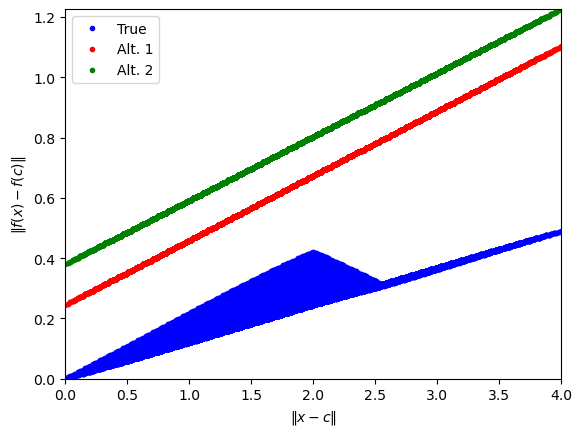

In [7]:
x1, x2 = torch.linspace(S.lower[0], S.upper[0], 100), torch.linspace(S.lower[1], S.upper[1], 100)
x = torch.stack(torch.meshgrid(x1, x2, indexing='ij'), dim=-1).flatten(start_dim=-3, end_dim=-2)

x_c = torch.linalg.vector_norm(x - c, dim=-1, ord=rho).pow(rho)
fx_fc = torch.linalg.vector_norm(f(x) - f(c), dim=-1, ord=rho).pow(rho)

with torch.no_grad():
    fig, ax = plt.subplots()
    ax.plot(x_c, fx_fc, 'b.', label='True')
    ax.plot(x_c, alpha_1 * x_c + beta_1, 'r.', label='Alt. 1')
    ax.plot(x_c, alpha_2 * x_c + beta_2, 'g.', label='Alt. 2')
    _ = ax.legend()
    _ = ax.autoscale(axis='both', tight=True)
    _ = ax.set_xlabel(r'$\|x-c\|$')
    _ = ax.set_ylabel(r'$\|f(x) - f(c)\|$')
    plt.show()

## Current Approach vs Alternative Approache 1 for separable Dynamics

Consider again dynamics $f$ of the form $f=sigmoid(Ax)$, but now with $A=diag(0.2, 0.7)$, and input region $S_i = [-\infty,1]\times [-\infty,1]$ and point $c=(1,1)^T$. Since the linear transformation is separable, i.e., matrix $A$ is diagonal, and the sigmoid operation is defined element-wise, the dynamics $f$ are now separable. Hence, the current linear bound propagation approach can be applied. Below, we compare the performance of all approaches for $\rho=1$. 

In [12]:
f = torch.nn.Sequential(Linear(torch.diag(torch.tensor([0.2, 0.7]))), act)

S = bp.HyperRectangle(torch.ones(1,2).fill_(-torch.inf), torch.ones(1,2))

# Current Approach
f_lb = linear_factory.build(f)
lb = f_lb.strict_crown_ibp(S, S.upper)

alpha = max(mat_norm(lb.lower[0], rho), mat_norm(lb.upper[0], rho)).pow(rho)
beta = 0.

# Alternative 1
f_ab = factory.build(f)
ab = f_ab.crown(bp.HyperRectangle(inf_to_large(S.lower), inf_to_large(S.upper)))

alpha_1 = max(mat_norm(ab.lower[0], rho), mat_norm(ab.upper[0], rho)).pow(rho)
beta_1 = 2 ** (rho - 1) * max(mat_norm(ab.lower[1] - ab.lower[0] @ c - f(c), rho),
                              mat_norm(ab.upper[1] - ab.upper[0] @ c - f(c), rho)).pow(rho)

# Approach 2
J = torch.autograd.functional.jacobian(f, c)

delta = 0.2
f_res = bp.Sub(f, torch.nn.Sequential(Linear(torch.eye(2), - c),  bp.Clamp(-delta, delta), Linear(J, f(c))))
ib = factory.build(f_res).ibp(bp.HyperRectangle(inf_to_large(S.lower), inf_to_large(S.upper)))

alpha_2 = 2**(rho-1) * mat_norm(J, rho).pow(rho)
beta_2 = 2**(rho-1) * max(vec_norm(ib.lower[0], rho), vec_norm(ib.upper[0], rho)).pow(rho)

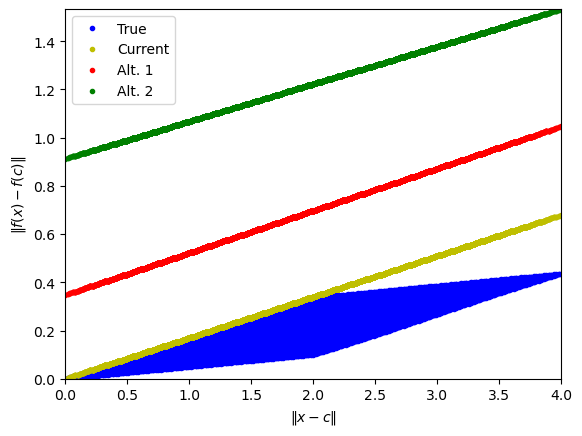

In [13]:
fx_fc = torch.linalg.vector_norm(f(x) - f(c), dim=-1, ord=rho).pow(rho)

with torch.no_grad():
    fig, ax = plt.subplots()
    ax.plot(x_c, fx_fc, 'b.', label='True')
    ax.plot(x_c, alpha * x_c + beta, 'y.', label='Current')
    ax.plot(x_c, alpha_1 * x_c + beta_1, 'r.', label='Alt. 1')
    ax.plot(x_c, alpha_2 * x_c + beta_2, 'g.', label='Alt. 2')
    _ = ax.legend()
    _ = ax.autoscale(axis='both', tight=True)
    _ = ax.set_xlabel(r'$\|x-c\|$')
    _ = ax.set_ylabel(r'$\|f(x) - f(c)\|$')
    plt.show()